# Best Win Model Evaluation

This notebook loads the saved production model for game-result prediction and prepares a 2025 test set using the same roster matchup feature logic from `workbook.ipynb`.

In [12]:
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
)

DATA_DIR = "data"
MODEL_PATH = os.path.join(DATA_DIR, "production_model.pkl")
TEST_SEASON = 2025

## Load Production Model and Source Data

In [13]:
with open(MODEL_PATH, "rb") as f:
    production_model = pickle.load(f)

teams = pd.read_csv(os.path.join(DATA_DIR, "starters_by_season.csv"))
games = pd.read_csv(os.path.join(DATA_DIR, "game_results.csv"))

print(f"Loaded model: {type(production_model).__name__}")
print(f"Teams shape: {teams.shape}")
print(f"Games shape: {games.shape}")

Loaded model: Pipeline
Teams shape: (2725, 26)
Games shape: (9503, 11)


## Feature Builder

These features mirror the matchup-prep flow used in `workbook.ipynb` and the production feature pipeline.

In [14]:
features = [
    "QB_diff",
    "OL_adv_1",
    "OL_adv_2",
    "WR_adv_1",
    "WR_adv_2",
    "RB_adv_1",
    "RB_adv_2",
    "TE_diff",
    "PK_diff",
    "P_diff",
    "QB1_vs_DB_2",
    "QB2_vs_DB_1",
    "PASS_SYNERGY_diff",
    "team_1_is_home",
]


def add_group_averages(teams_df):
    teams_df = teams_df.copy()
    teams_df["OL_avg"] = teams_df[[f"OL{i}" for i in range(1, 6)]].mean(axis=1)
    teams_df["WR_avg"] = teams_df[[f"WR{i}" for i in range(1, 3)]].mean(axis=1)
    teams_df["DL_avg"] = teams_df[[f"DL{i}" for i in range(1, 5)]].mean(axis=1)
    teams_df["LB_avg"] = teams_df[[f"LB{i}" for i in range(1, 4)]].mean(axis=1)
    teams_df["DB_avg"] = teams_df[[f"DB{i}" for i in range(1, 5)]].mean(axis=1)
    return teams_df


def build_matchup_row(year, team_1, team_2, team_1_is_home, team_1_won, teams_df):
    t1 = teams_df[(teams_df.season == year) & (teams_df.team == team_1)]
    t2 = teams_df[(teams_df.season == year) & (teams_df.team == team_2)]

    team_1_synergy = (
        2.0 * t1.QB1.iloc[0] + 1.0 * t1.WR_avg.iloc[0] + 0.8 * t1.TE1.iloc[0]
    ) / 3.8
    team_2_synergy = (
        2.0 * t2.QB1.iloc[0] + 1.0 * t2.WR_avg.iloc[0] + 0.8 * t2.TE1.iloc[0]
    ) / 3.8

    return {
        "QB_diff": t1.QB1.iloc[0] - t2.QB1.iloc[0],
        "OL_adv_1": t1.OL_avg.iloc[0] - t2.DL_avg.iloc[0],
        "OL_adv_2": t2.OL_avg.iloc[0] - t1.DL_avg.iloc[0],
        "WR_adv_1": t1.WR_avg.iloc[0] - t2.DB_avg.iloc[0],
        "WR_adv_2": t2.WR_avg.iloc[0] - t1.DB_avg.iloc[0],
        "RB_adv_1": t1.RB1.iloc[0] - t2.LB_avg.iloc[0],
        "RB_adv_2": t2.RB1.iloc[0] - t1.LB_avg.iloc[0],
        "TE_diff": t1.TE1.iloc[0] - t2.TE1.iloc[0],
        "PK_diff": t1.PK1.iloc[0] - t2.PK1.iloc[0],
        "P_diff": t1.P1.iloc[0] - t2.P1.iloc[0],
        "QB1_vs_DB_2": t1.QB1.iloc[0] - t2.DB_avg.iloc[0],
        "QB2_vs_DB_1": t2.QB1.iloc[0] - t1.DB_avg.iloc[0],
        "PASS_SYNERGY_diff": team_1_synergy - team_2_synergy,
        "team_1_is_home": team_1_is_home,
        "season": year,
        "team_1": team_1,
        "team_2": team_2,
        "target": team_1_won,
    }


def build_xy(df, teams_df, train=True):
    rows = []
    for year, home, away, home_won in df[
        ["season", "homeTeam", "awayTeam", "target"]
    ].itertuples(index=False):
        rows.append(build_matchup_row(year, home, away, 1, home_won, teams_df))
        if train:
            rows.append(build_matchup_row(year, away, home, 0, 1 - home_won, teams_df))
    return pd.DataFrame(rows)

## Prepare 2025 Test Data

In [15]:
teams_prepped = add_group_averages(teams.fillna(0.0))

games_prepped = games.rename(
    columns={
        "home_team": "homeTeam",
        "away_team": "awayTeam",
        "home_points": "homePoints",
        "away_points": "awayPoints",
        "year": "season",
        "season_type": "seasonType",
        "start_date": "startDate",
    }
).copy()

test_raw_data = games_prepped[
    (games_prepped["season"] == TEST_SEASON)
    & (games_prepped["seasonType"] == "regular")
    & games_prepped["homePoints"].notna()
    & games_prepped["awayPoints"].notna()
    & (games_prepped["homePoints"] != games_prepped["awayPoints"])
].copy()

available_rosters = set(
    zip(teams_prepped["season"], teams_prepped["team"])
)
test_raw_data["home_key"] = list(zip(test_raw_data["season"], test_raw_data["homeTeam"]))
test_raw_data["away_key"] = list(zip(test_raw_data["season"], test_raw_data["awayTeam"]))

missing_roster_mask = ~test_raw_data["home_key"].isin(available_rosters) | ~test_raw_data[
    "away_key"
].isin(available_rosters)
dropped_missing_roster = test_raw_data.loc[missing_roster_mask].copy()
test_raw_data = test_raw_data.loc[~missing_roster_mask].copy()
test_raw_data["target"] = (test_raw_data["homePoints"] > test_raw_data["awayPoints"]).astype(int)

Xy_test = build_xy(test_raw_data, teams_prepped, train=False)
X_test = Xy_test[features]
y_test = Xy_test["target"]

print(f"Completed {TEST_SEASON} regular-season games before roster filtering: {len(test_raw_data) + len(dropped_missing_roster)}")
print(f"Games dropped because at least one team lacked roster data: {len(dropped_missing_roster)}")
print(f"Final 2025 test games: {len(Xy_test)}")
Xy_test.head()

Completed 2025 regular-season games before roster filtering: 888
Games dropped because at least one team lacked roster data: 0
Final 2025 test games: 888


,QB_diff,OL_adv_1,OL_adv_2,WR_adv_1,WR_adv_2,RB_adv_1,RB_adv_2,TE_diff,PK_diff,P_diff,QB1_vs_DB_2,QB2_vs_DB_1,PASS_SYNERGY_diff,team_1_is_home,season,team_1,team_2,target
0,0.0,0.40,-0.50,0.00,-0.25,0.666667,-0.666667,1.0,0.0,0.0,1.00,0.75,0.210526,1,2025,Kansas State,Iowa State,0
1,3.0,3.00,-3.25,3.25,-4.00,4.000000,-3.666667,3.0,3.0,0.0,2.25,-4.00,3.263158,1,2025,UNLV,Idaho State,1
2,0.0,-0.10,-0.75,0.50,-0.50,0.000000,1.000000,0.0,0.0,0.0,0.00,-0.50,0.131579,1,2025,Kansas,Fresno State,1
3,-1.0,0.35,-1.20,0.00,0.00,2.000000,0.000000,0.0,1.0,0.0,0.00,1.00,-0.526316,1,2025,Western Kentucky,Sam Houston,1
4,-1.0,-0.25,0.15,0.50,0.50,-1.000000,0.000000,-1.0,-3.0,-3.0,0.00,1.00,-0.736842,1,2025,Hawai'i,Stanford,1


## Predict 2025 Game Results

In [16]:
y_pred = production_model.predict(X_test)
y_prob = production_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
test_log_loss = log_loss(y_test, y_prob)

print(f"Production model 2025 accuracy: {accuracy:.4f}")
print(f"Production model 2025 ROC AUC: {roc_auc:.4f}")
print(f"Production model 2025 log loss: {test_log_loss:.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Production model 2025 accuracy: 0.6610
Production model 2025 ROC AUC: 0.6931
Production model 2025 log loss: 0.5845

Confusion matrix:
[[114 201]
 [100 473]]

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.36      0.43       315
           1       0.70      0.83      0.76       573

    accuracy                           0.66       888
   macro avg       0.62      0.59      0.59       888
weighted avg       0.64      0.66      0.64       888



## ROC Curve

This plot shows the tradeoff between true positive rate and false positive rate across probability thresholds.

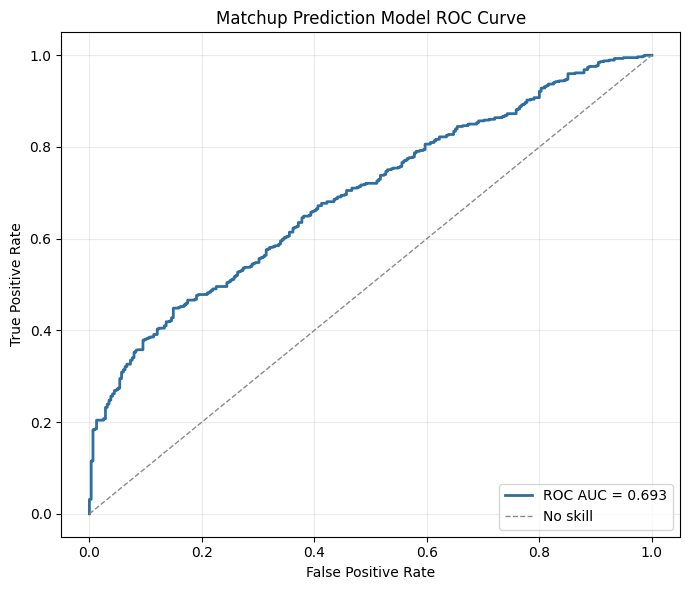

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#2f6f9f", linewidth=2, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color="#8a8a8a", linestyle="--", linewidth=1, label="No skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Matchup Prediction Model ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Feature Weight Analysis

The production model is a tree-based model, so these weights come from the model's feature importances. Directional duplicate features are combined by averaging their importances. For example, `OL_adv_1` and `OL_adv_2` are shown as one `OL_adv` feature.

In [18]:
final_model = production_model.named_steps.get("model", production_model)

if hasattr(final_model, "feature_importances_"):
    raw_weights = final_model.feature_importances_
    weight_label = "Feature Importance"
elif hasattr(final_model, "coef_"):
    raw_weights = abs(final_model.coef_).ravel()
    weight_label = "Absolute Coefficient"
else:
    raise AttributeError("The production model does not expose feature_importances_ or coef_.")

feature_weight_df = pd.DataFrame(
    {
        "feature": features,
        "raw_weight": raw_weights,
    }
)

combined_feature_map = {
    "OL_adv_1": "OL_adv",
    "OL_adv_2": "OL_adv",
    "WR_adv_1": "WR_adv",
    "WR_adv_2": "WR_adv",
    "RB_adv_1": "RB_adv",
    "RB_adv_2": "RB_adv",
    "QB1_vs_DB_2": "QB_vs_DB",
    "QB2_vs_DB_1": "QB_vs_DB",
    "team_1_is_home": "homefield_adv",
    "PASS_SYNERGY_diff": "Pass_Off_diff",
}

feature_weight_df["display_feature"] = feature_weight_df["feature"].replace(combined_feature_map)
combined_feature_weights = (
    feature_weight_df.groupby("display_feature", as_index=False)["raw_weight"]
    .mean()
    .rename(columns={"display_feature": "feature", "raw_weight": "weight"})
    .sort_values("weight", ascending=False)
)

combined_feature_weights

,feature,weight
0,OL_adv,0.152803
9,homefield_adv,0.125089
3,Pass_Off_diff,0.109443
8,WR_adv,0.095175
6,RB_adv,0.068013
5,QB_vs_DB,0.038477
2,P_diff,0.022391
7,TE_diff,0.019716
4,QB_diff,0.010671
1,PK_diff,0.003754


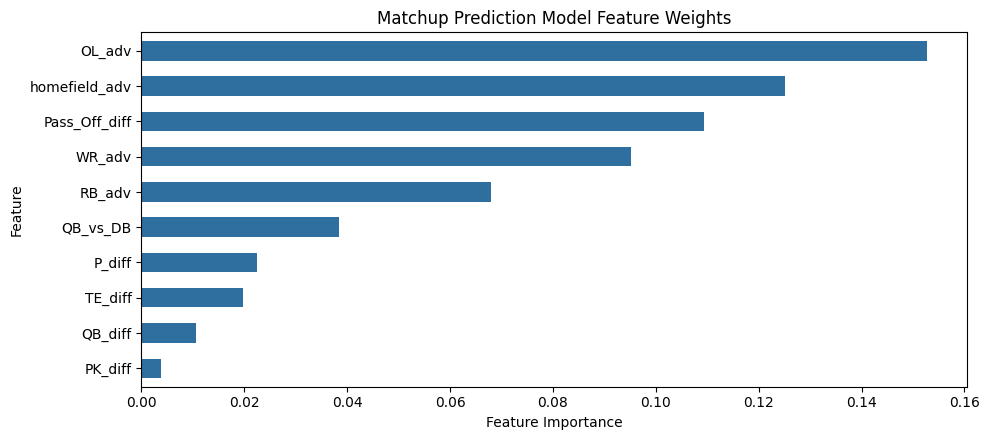

In [25]:
plot_df = combined_feature_weights.sort_values("weight", ascending=True)

ax = plot_df.plot.barh(
    x="feature",
    y="weight",
    figsize=(10, 4.5),
    legend=False,
    color="#2f6f9f",
    width=0.55,
)
ax.set_xlabel(weight_label)
ax.set_ylabel("Feature")
ax.set_title("Matchup Prediction Model Feature Weights")
plt.tight_layout()
plt.show()

In [20]:
prediction_cols = [
    "id",
    "season",
    "week",
    "startDate",
    "homeTeam",
    "awayTeam",
    "homePoints",
    "awayPoints",
]
prediction_cols = [col for col in prediction_cols if col in test_raw_data.columns]
predictions = test_raw_data[prediction_cols].reset_index(drop=True)
predictions["home_win_actual"] = y_test.reset_index(drop=True)
predictions["home_win_predicted"] = y_pred
predictions["home_win_probability"] = y_prob
predictions["correct"] = predictions["home_win_actual"] == predictions["home_win_predicted"]

predictions.sort_values("home_win_probability", ascending=False).head(10)

,id,season,startDate,homeTeam,awayTeam,homePoints,awayPoints,home_win_actual,home_win_predicted,home_win_probability,correct
56,401752804,2025,2025-08-30T20:00:00.000Z,Oregon,Montana State,59,13,1,1,0.974784,True
102,401754621,2025,2025-09-06T16:00:00.000Z,Florida State,East Texas A&M,77,3,1,1,0.972398,True
72,401756877,2025,2025-08-30T23:30:00.000Z,Texas Tech,Arkansas-Pine Bluff,67,7,1,1,0.968903,True
70,401756855,2025,2025-08-30T23:00:00.000Z,Kansas State,North Dakota,38,35,1,1,0.966238,True
64,401752679,2025,2025-08-30T23:00:00.000Z,Vanderbilt,Charleston Southern,45,3,1,1,0.965118,True
85,401754521,2025,2025-08-31T01:00:00.000Z,SMU,East Texas A&M,42,13,1,1,0.964953,True
181,401754532,2025,2025-09-12T23:00:00.000Z,Syracuse,Colgate,66,24,1,1,0.964953,True
121,401752815,2025,2025-09-06T19:30:00.000Z,Ohio State,Grambling,70,0,1,1,0.964319,True
219,401752701,2025,2025-09-13T22:00:00.000Z,Mississippi State,Alcorn State,63,0,1,1,0.963302,True
301,401752710,2025,2025-09-20T23:45:00.000Z,LSU,SE Louisiana,56,10,1,1,0.962241,True


In [21]:
incorrect = predictions.loc[~predictions["correct"]].copy()
print(f"Incorrect predictions: {len(incorrect)} of {len(predictions)}")
incorrect.sort_values("home_win_probability", ascending=False).head(10)

Incorrect predictions: 301 of 888


,id,season,startDate,homeTeam,awayTeam,homePoints,awayPoints,home_win_actual,home_win_predicted,home_win_probability,correct
151,401762795,2025,2025-09-06T23:00:00.000Z,Eastern Michigan,Long Island University,23,28,0,1,0.956929,False
184,401752837,2025,2025-09-13T02:00:00.000Z,UCLA,New Mexico,10,35,0,1,0.930212,False
138,401752684,2025,2025-09-06T20:15:00.000Z,Florida,South Florida,16,18,0,1,0.889938,False
118,401762816,2025,2025-09-06T19:30:00.000Z,Massachusetts,Bryant,26,27,0,1,0.885890,False
857,401762441,2025,2025-11-29T20:30:00.000Z,UTSA,Army,24,27,0,1,0.872504,False
449,401752866,2025,2025-10-11T19:30:00.000Z,Penn State,Northwestern,21,22,0,1,0.870718,False
813,401762516,2025,2025-11-28T00:30:00.000Z,Memphis,Navy,17,28,0,1,0.870617,False
155,401756882,2025,2025-09-06T23:00:00.000Z,Kansas State,Army,21,24,0,1,0.866078,False
647,401752893,2025,2025-11-08T17:00:00.000Z,Penn State,Indiana,24,27,0,1,0.865082,False
886,401777353,2025,2025-12-07T01:00:00.000Z,Ohio State,Indiana,10,13,0,1,0.846708,False


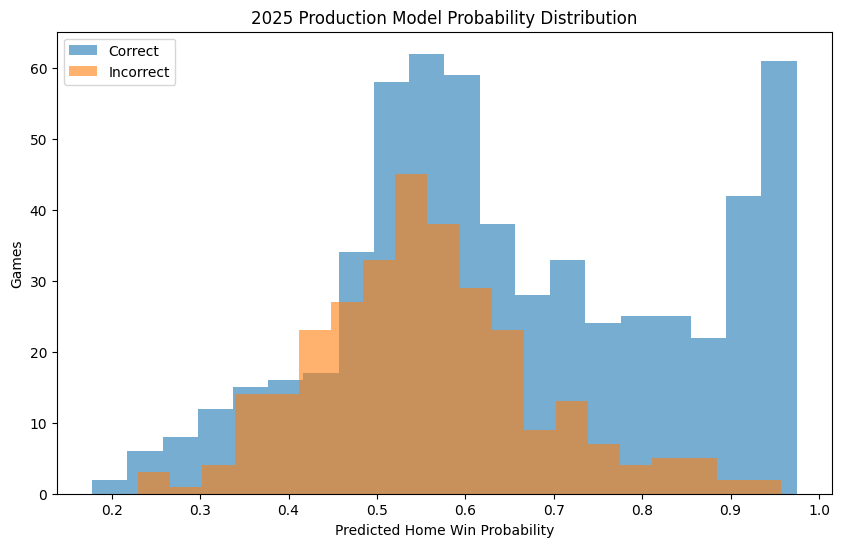

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(predictions.loc[predictions["correct"], "home_win_probability"], alpha=0.6, bins=20, label="Correct")
plt.hist(predictions.loc[~predictions["correct"], "home_win_probability"], alpha=0.6, bins=20, label="Incorrect")
plt.xlabel("Predicted Home Win Probability")
plt.ylabel("Games")
plt.title("2025 Production Model Probability Distribution")
plt.legend()
plt.show()